# PCE + NLL boxplots by prerank

This notebook aggregates the 18 multivariate benchmark datasets across seeds, then:
- Plots **overall** boxplots (across datasets) per prerank, using seed-averaged metrics.
- Plots **per-dataset** boxplots per prerank, using seed-level values (5 runs) and mean overlays.

Figures are written to `Projected_PIT_calibration/figures/pce_nll_boxplots/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
def find_csv_dir(start: Path) -> Path:
    candidates = [
        start / "csv-files",
        start / "Projected_PIT_calibration" / "csv-files",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    for parent in start.parents:
        for rel in ("csv-files", "Projected_PIT_calibration/csv-files"):
            candidate = parent / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError("Could not find csv-files directory.")

CSV_DIR = find_csv_dir(Path.cwd())
CSV_DIR

PosixPath('/mnt/default/aya/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/csv-files')

In [38]:
patterns = [
    "NEW-metrics-from-model-trained-on-train_prerank=*.csv",
]

files = []
for pattern in patterns:
    files.extend(sorted(CSV_DIR.glob(pattern)))

if not files:
    raise FileNotFoundError(f"No files matched {patterns} in {CSV_DIR}")


def load_metrics(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["source_file"] = path.name
    if "train_prerank" not in df.columns and "train_prerank=" in path.name:
        df["train_prerank"] = path.stem.split("train_prerank=")[-1]
    return df


df = pd.concat([load_metrics(path) for path in files], ignore_index=True)
df.head()

,data_name,seed,train_prerank,train_time_seconds,epochs_trained,best_epoch,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,source_file
0,households,0,cdf,355.106159,110,94,3.374301,0.955502,0.658178,0.083509,0.081250,0.138460,0.020747,0.067019,0.138793,0.119877,NEW-metrics-from-model-trained-on-train_preran...
1,households,42,cdf,414.930414,127,111,3.151952,0.926092,0.634717,0.096039,0.089596,0.131760,0.023430,0.071748,0.106999,0.150038,NEW-metrics-from-model-trained-on-train_preran...
2,households,866,cdf,387.485584,118,102,3.265174,0.939988,0.644778,0.092788,0.093254,0.125175,0.017523,0.067374,0.096430,0.144793,NEW-metrics-from-model-trained-on-train_preran...
3,households,12,cdf,350.914541,106,90,3.139041,0.912886,0.611012,0.098924,0.093299,0.132409,0.024299,0.065884,0.098955,0.160288,NEW-metrics-from-model-trained-on-train_preran...
4,households,4,cdf,472.756453,145,129,3.128845,0.903059,0.606668,0.101546,0.104639,0.113672,0.020384,0.070082,0.099377,0.155110,NEW-metrics-from-model-trained-on-train_preran...


In [9]:
df[df.data_name == "households"]

,data_name,seed,train_prerank,train_time_seconds,epochs_trained,best_epoch,nll,energy,mse,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,source_file
0,households,0,cdf,355.106159,110,94,3.374301,0.955502,0.658178,0.083509,0.081250,0.138460,0.020747,0.067019,0.138793,0.119877,NEW-metrics-from-model-trained-on-train_preran...
1,households,42,cdf,414.930414,127,111,3.151952,0.926092,0.634717,0.096039,0.089596,0.131760,0.023430,0.071748,0.106999,0.150038,NEW-metrics-from-model-trained-on-train_preran...
2,households,866,cdf,387.485584,118,102,3.265174,0.939988,0.644778,0.092788,0.093254,0.125175,0.017523,0.067374,0.096430,0.144793,NEW-metrics-from-model-trained-on-train_preran...
3,households,12,cdf,350.914541,106,90,3.139041,0.912886,0.611012,0.098924,0.093299,0.132409,0.024299,0.065884,0.098955,0.160288,NEW-metrics-from-model-trained-on-train_preran...
4,households,4,cdf,472.756453,145,129,3.128845,0.903059,0.606668,0.101546,0.104639,0.113672,0.020384,0.070082,0.099377,0.155110,NEW-metrics-from-model-trained-on-train_preran...
75,households,0,density,328.519302,111,95,3.333978,0.939959,0.644002,0.099745,0.100289,0.119361,0.020268,0.068063,0.078663,0.151933,NEW-metrics-from-model-trained-on-train_preran...
76,households,42,density,575.452130,146,130,3.145659,0.926613,0.630800,0.106513,0.099886,0.116129,0.022937,0.073033,0.097015,0.172993,NEW-metrics-from-model-trained-on-train_preran...
77,households,866,density,578.352904,142,126,3.152287,0.924879,0.625867,0.098710,0.100661,0.109855,0.017093,0.070895,0.063085,0.153045,NEW-metrics-from-model-trained-on-train_preran...
78,households,12,density,492.262964,121,105,3.284427,0.917100,0.607169,0.099490,0.096701,0.120010,0.021364,0.069040,0.100263,0.161612,NEW-metrics-from-model-trained-on-train_preran...
79,households,4,density,475.022673,112,96,3.193414,0.909481,0.609591,0.107545,0.107033,0.105793,0.022432,0.071466,0.073277,0.164749,NEW-metrics-from-model-trained-on-train_preran...


In [18]:
df_without_reg = pd.read_csv("/mnt/default/aya/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/csv-files/metrics-from-model-without-reg.csv")

In [27]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
pce_cols = [c for c in avg_df_without_reg.columns if c.startswith("pce_")]


long_df_without_reg = avg_df_without_reg.melt(
    id_vars=["data_name", "nll"],      # columns to keep
    value_vars=pce_cols,              # columns to unpivot
    var_name="train_prerank",         # new column holding former col names
    value_name="pce_mean",
)

long_df_without_reg["train_prerank"] = (
    long_df_without_reg["train_prerank"].str.replace("pce_", "", regex=False)
)

long_df_without_reg = long_df_without_reg.rename(columns={"nll": "nll_mean"})

long_df_without_reg["method"] = "without_reg"  # change label if you want

long_df_without_reg.head()

In [22]:
prerank_order = ["cdf", "density", "dependency", "marginal", "mean", "pca", "variance"]

pce_cols = [col for col in df.columns if col.startswith("pce_")]

if not pce_cols:
    raise ValueError("No pce_* columns found in the CSVs.")

# Select the pce_<train_prerank> column for each row
col_index = pd.Index(pce_cols).get_indexer("pce_" + df["train_prerank"].astype(str))
values = df[pce_cols].to_numpy()
row_index = np.arange(len(df))

pce_selected = np.where(
    col_index >= 0,
    values[row_index, col_index],
    np.nan,
)

metrics_df = df[["data_name", "train_prerank", "seed", "nll"]].copy()
metrics_df["pce_selected"] = pce_selected

metrics_df = metrics_df.dropna(subset=["pce_selected", "nll"])
metrics_df.head()

,data_name,train_prerank,seed,nll,pce_selected
0,households,cdf,0,3.374301,0.119877
1,households,cdf,42,3.151952,0.150038
2,households,cdf,866,3.265174,0.144793
3,households,cdf,12,3.139041,0.160288
4,households,cdf,4,3.128845,0.155110


In [41]:
# Aggregate over seeds for the across-dataset boxplots
seed_avg = (
    metrics_df.groupby(["data_name", "train_prerank"], dropna=False)
    .agg(nll_mean=("nll", "mean"), pce_mean=("pce_selected", "mean"))
    .reset_index()
)
seed_avg["method"] = "with_reg"

seed_avg.head()

,data_name,train_prerank,nll_mean,pce_mean,method
0,air,cdf,5.594623,0.146318,with_reg
1,air,density,5.621278,0.087404,with_reg
2,air,dependency,5.616154,0.050665,with_reg
3,air,marginal,5.591807,0.096457,with_reg
4,air,mean,5.587274,0.092217,with_reg


In [ ]:
final_df = pd.concat(
    [seed_avg, long_df_without_reg],
    ignore_index=True
)

sns.boxplot(
    data=final_df,
    x="train_prerank",
    y="pce_mean",
    hue="method"
)

In [ ]:
def set_pub_style():
    sns.set_theme(context="paper", style="whitegrid")
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 400,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.0,
        "pdf.fonttype": 42,   # embed fonts nicely
        "ps.fonttype": 42,
    })


def get_prerank_order(values, prerank_order):
    ordered = [p for p in prerank_order if p in values]
    remaining = [p for p in values if p not in ordered]
    return ordered + sorted(remaining)

def pretty_label(x: str) -> str:
    # adjust to match the paper’s labels if you want
    mapping = {
        "dependency": "Dep.",
        "pca": "PCA",
        "marginal": "Marginal",
        "density": "HDR",
        "cdf": "Copula",
        "mean": "Location",
        "variance": "Scale",
    }
    return mapping.get(str(x), str(x))

def order_by_mean(data, x_col, y_col):
    return (
        data.groupby(x_col)[y_col]
        .mean()
        .sort_values()
        .index
        .tolist()
    )

In [43]:
def plot_grouped_boxplot(
    data,
    metric_col,
    ylabel,
    filename_base,
    prerank_order,
    x_col="train_prerank",
    hue_col="method",
    hue_order=None,
    palette=None,
    title=None,
    show_points=True,
    show_means=False,
    ylim=None,
):
    set_pub_style()

    # order = get_prerank_order(data[x_col].unique().tolist(), prerank_order)

    order = order_by_mean(data, "train_prerank", metric_col)

    if palette is None:
        palette = ["#E69F00", "#56B4E9"]  # orange / blue
    if hue_order is None and hue_col in data.columns:
        hue_order = list(data[hue_col].dropna().unique())

    fig, ax = plt.subplots(figsize=(7.6, 3.6))

    sns.boxplot(
        data=data,
        x=x_col,
        y=metric_col,
        hue=hue_col if hue_col in data.columns else None,
        order=order,
        hue_order=hue_order,
        palette=palette if hue_col in data.columns else None,
        width=0.65,
        linewidth=0.9,
        fliersize=2.2,
        whis=1.5,
        ax=ax,
    )

    if show_points:
        sns.stripplot(
            data=data,
            x=x_col,
            y=metric_col,
            hue=hue_col if hue_col in data.columns else None,
            order=order,
            hue_order=hue_order,
            dodge=True if hue_col in data.columns else False,
            alpha=0.45,
            size=2.2,
            jitter=0.18,
            linewidth=0,
            palette=["#000000"] * len(hue_order) if hue_col in data.columns else None,  # points in black-ish
            ax=ax,
        )

    if show_means and hue_col in data.columns:
        means = (
            data.groupby([x_col, hue_col], dropna=False)[metric_col]
            .mean()
            .reset_index()
        )
        sns.pointplot(
            data=means,
            x=x_col,
            y=metric_col,
            hue=hue_col,
            order=order,
            hue_order=hue_order,
            dodge=0.45,
            join=False,
            markers="o",
            scale=0.55,
            errwidth=0,
            ax=ax,
        )

    # Clean up legend: stripplot duplicates legend entries; keep one
    if hue_col in data.columns:
        handles, labels = ax.get_legend_handles_labels()
        # Keep only the first set matching hue_order length
        if hue_order is not None and len(handles) >= len(hue_order):
            ax.legend(handles[:len(hue_order)], labels[:len(hue_order)],
                      title=None, frameon=False, loc="upper left")
        else:
            ax.legend(title=None, frameon=False, loc="upper left")

    # Labels + formatting
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=6)

    ax.set_xticklabels([pretty_label(t.get_text()) for t in ax.get_xticklabels()],
                       rotation=0)

    ax.grid(axis="y", alpha=0.35)
    sns.despine(ax=ax, trim=True)

    if ylim is not None:
        ax.set_ylim(ylim)

    fig.tight_layout()

    # # Save publication formats
    # fig.savefig(FIG_DIR / f"{filename_base}.pdf", bbox_inches="tight")
    # fig.savefig(FIG_DIR / f"{filename_base}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

/mnt/default/ipykernel_3368934/2156790754.py:67: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/mnt/default/ipykernel_3368934/2156790754.py:67: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/mnt/default/ipykernel_3368934/2156790754.py:67: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.pointplot(
/mnt/default/ipykernel_3368934/2156790754.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([pretty_label(t.get_text()) for t in ax.get_xticklabels()],


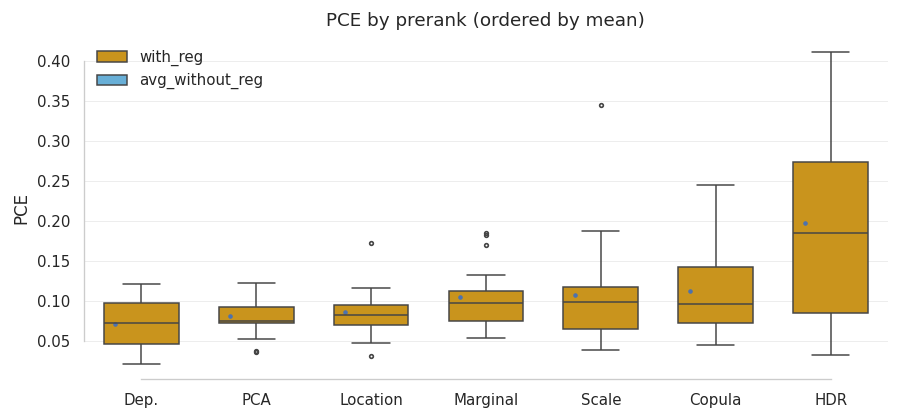

In [44]:
plot_grouped_boxplot(
    data=seed_avg,
    metric_col="pce_mean",
    ylabel="PCE",
    title="PCE by prerank (ordered by mean)",
    filename_base="overall_pce_boxplot_pub",
    prerank_order=prerank_order,
    hue_col="method",
    hue_order=["with_reg", "avg_without_reg"],
    show_points=False,
    show_means=True,
)

In [52]:
def find_csv_dir(start: Path) -> Path:
    candidates = [
        start / "logs/2026-01-19",
        start / "Projected_PIT_calibration" / "logs/2026-01-19",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    for parent in start.parents:
        for rel in ("logs", "Projected_PIT_calibration/logs/2026-01-19"):
            candidate = parent / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError("Could not find csv-files directory.")

dir = find_csv_dir(Path.cwd())
dir

PosixPath('/mnt/default/aya/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2026-01-19')

In [56]:
eval_preranks = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]

In [59]:
# --- imports + helpers ---
from pathlib import Path
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.datamodules.real_datamodule import RealDataModule
from moc.metrics.distribution_metrics import pce

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = get_config()
config.device = "cuda" if device.type == "cuda" else "cpu"

alphas = torch.linspace(0, 1, 100).cpu().numpy()

def _plot_reliability(ax, cdf, pce, title=None):
    ax.plot(alphas, cdf, color="0.2", lw=1, label=f"PCE={pce:.3f}")
    ax.plot([0, 1], [0, 1], "r--", lw=0.8)
    if title:
        ax.set_title(title, fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.5, 1])
    ax.grid(alpha=0.2, linestyle="--")

# --- scan checkpoints + compute PIT grid ---
def scan_ckpts(log_root):
    ckpts = {}
    for p in log_root.rglob("epoch_*.ckpt"):
        try:
            rel = p.relative_to(log_root)
            data_group, data_name, model_dir = rel.parts[1], rel.parts[2], rel.parts[3]
        except Exception:
            continue
        m = re.search(r"seed=(\d+).*prerank=([^,]+)", model_dir)
        if not m:
            continue
        seed = int(m.group(1))
        prerank = m.group(2)
        em = re.search(r"epoch_(\d+)", p.name)
        epoch = int(em.group(1)) if em else -1
        key = (prerank, data_group, data_name, seed)
        if key not in ckpts or epoch > ckpts[key][0]:
            ckpts[key] = (epoch, p)
    return ckpts

def _mean_cdf_and_pce(cdfs, pces):
    return cdfs.mean(dim=0).cpu(), float(pces.mean())


def pit_curves_all_preranks(ckpt_path, data_group, data_name, train_prerank, seed):
    hparams = {"model": "mixture", "seed": seed, "prerank": train_prerank, "lambda": 0.1}
    rc = RunConfig(config, data_group, data_name, hparams=hparams, seed=seed)
    dm = RealDataModule(rc, num_workers=0, seed=seed)
    model = MixtureLightningModule.load_from_checkpoint(ckpt_path).eval().to(device)

    acc = {pr: {"cdf": None, "pce": 0.0, "n": 0} for pr in eval_preranks}

    for x, y, _ in dm.test_dataloader():
        x, y = x.to(device), y.to(device)
        dist = model.predict(x)
        for pr in eval_preranks:
            pces, cdfs = pce(dist, y, n_samples=10000, prerank=pr, setup="real")
            cdf_mean, pce_mean = _mean_cdf_and_pce(cdfs, pces)
            a = acc[pr]
            a["cdf"] = cdf_mean if a["cdf"] is None else (a["cdf"] + cdf_mean)
            a["pce"] += pce_mean
            a["n"] += 1

    out = {}
    for pr in eval_preranks:
        a = acc[pr]
        out[pr] = (a["cdf"] / a["n"]).numpy(), a["pce"] / a["n"]
    return out

def pit_curve_for_ckpt(ckpt_path, data_group, data_name, prerank, seed):
    hparams = {"model": "mixture", "seed": seed, "prerank": prerank, "lambda": 0.1}
    rc = RunConfig(config, data_group, data_name, hparams=hparams, seed=seed)
    dm = RealDataModule(rc, num_workers=0, seed=seed)
    model = MixtureLightningModule.load_from_checkpoint(ckpt_path).eval().to(device)

    cdf_sum, pce_sum, n = None, 0.0, 0
    for x, y, _ in dm.test_dataloader():
        x, y = x.to(device), y.to(device)
        dist = model.predict(x)
        pces, cdfs = pce(dist, y, n_samples=model.hparams.es_num_samples, prerank=prerank, setup="real")
        cdf_mean, pce_mean = _mean_cdf_and_pce(cdfs, pces)
        cdf_sum = cdf_mean if cdf_sum is None else (cdf_sum + cdf_mean)
        pce_sum += pce_mean
        n += 1
    return (cdf_sum / n).numpy(), pce_sum / n


eval_preranks = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]

def pit_curve_for_dataset(ckpts, prerank, data_group, data_name):
    items = [(seed, p) for (pr, g, d, seed), (_, p) in ckpts.items()
             if pr == prerank and g == data_group and d == data_name]
    if not items:
        return None
    cdf_sum, pce_sum, n = None, 0.0, 0
    for seed, p in items:
        cdf, pce_val = pit_curve_for_ckpt(p, data_group, data_name, prerank, seed)
        cdf_sum = cdf if cdf_sum is None else (cdf_sum + cdf)
        pce_sum += pce_val
        n += 1
    return cdf_sum / n, pce_sum / n

In [60]:
ckpts = scan_ckpts(dir)

preranks = sorted({k[0] for k in ckpts})
datasets = sorted({(k[1], k[2]) for k in ckpts}, key=lambda x: f"{x[0]}/{x[1]}")

datasets = datasets[6:12]

In [ ]:
fig, axs = plt.subplots(len(preranks), len(datasets),
                        figsize=(2.1 * len(datasets), 2.0 * len(preranks)),
                        sharex=True, sharey=True)

for i, pr in enumerate(preranks):
    for j, (g, d) in enumerate(datasets):
        ax = axs[i, j] if len(preranks) > 1 else axs[j]
        out = pit_curve_for_dataset(ckpts, pr, g, d)
        if out is None:
            ax.axis("off")
            continue
        cdf, pce_val = out
        title = f"{g}/{d}" if i == 0 else None
        _plot_reliability(ax, cdf, pce_val, title=title)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)

plt.tight_layout()
plt.show()

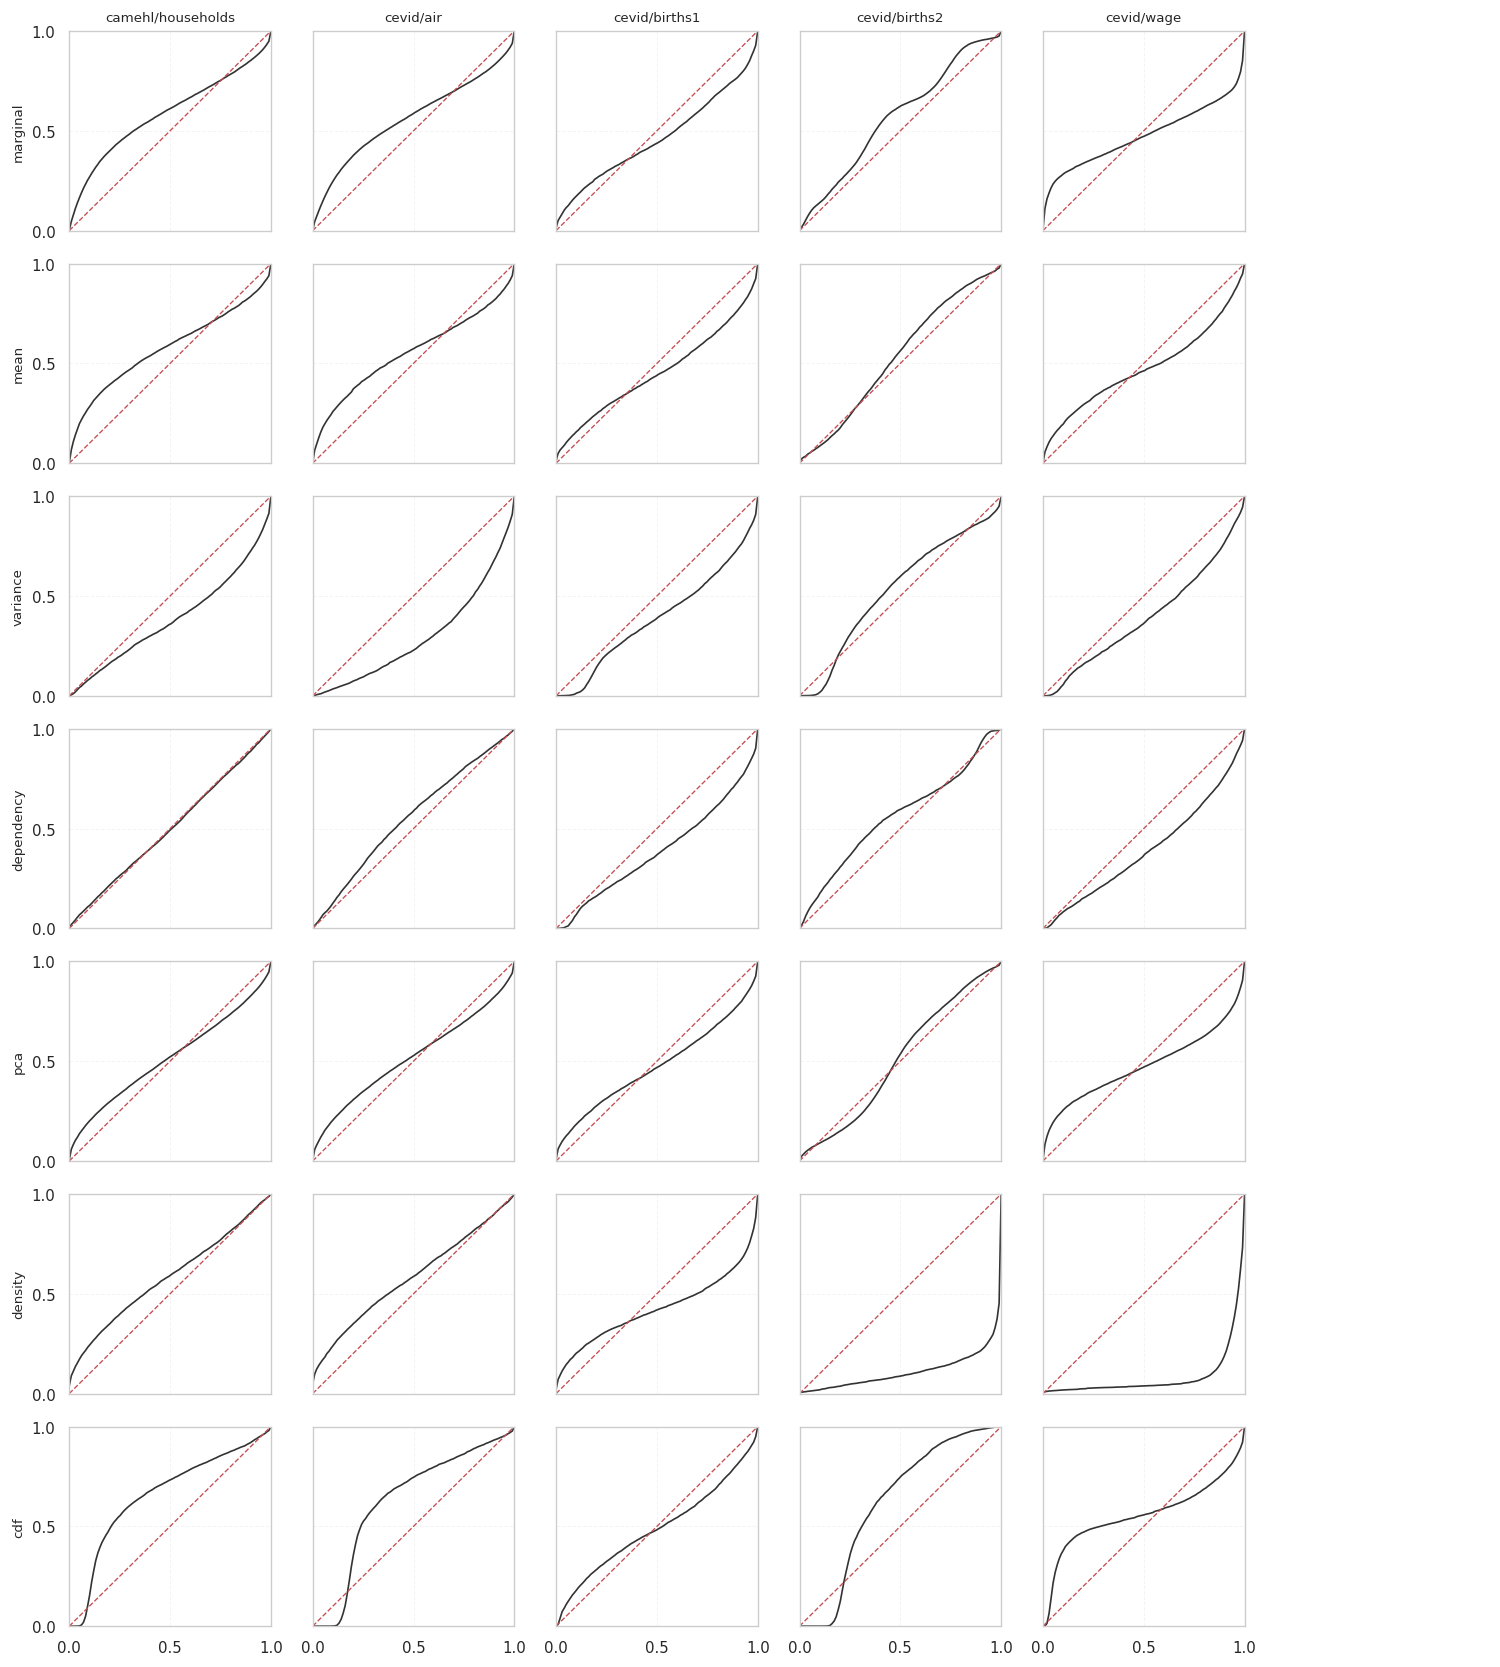

In [58]:
train_prerank = "density"  # choose the pretrained model you want to evaluate

fig, axs = plt.subplots(len(eval_preranks), len(datasets),
                        figsize=(2.1 * len(datasets), 2.0 * len(eval_preranks)),
                        sharex=True, sharey=True)

for j, (g, d) in enumerate(datasets):
    # use the latest ckpt for this train_prerank + dataset, average across seeds
    items = [(seed, p) for (pr, gg, dd, seed), (_, p) in ckpts.items()
             if pr == train_prerank and gg == g and dd == d]
    if not items:
        for i in range(len(eval_preranks)):
            axs[i, j].axis("off")
        continue

    # average across seeds
    agg = {pr: {"cdf": None, "pce": 0.0, "n": 0} for pr in eval_preranks}
    for seed, p in items:
        curves = pit_curves_all_preranks(p, g, d, train_prerank, seed)
        for i, pr in enumerate(eval_preranks):
            cdf, pce_val = curves[pr]
            a = agg[pr]
            a["cdf"] = cdf if a["cdf"] is None else (a["cdf"] + cdf)
            a["pce"] += pce_val
            a["n"] += 1

    for i, pr in enumerate(eval_preranks):
        ax = axs[i, j] if len(eval_preranks) > 1 else axs[j]
        cdf = agg[pr]["cdf"] / agg[pr]["n"]
        pce_val = agg[pr]["pce"] / agg[pr]["n"]
        title = f"{d}" if i == 0 else None
        _plot_reliability(ax, cdf, pce_val, title=title)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
train_prerank = "pca"  # choose the pretrained model you want to evaluate

fig, axs = plt.subplots(len(eval_preranks), len(datasets),
                        figsize=(2.1 * len(datasets), 2.0 * len(eval_preranks)),
                        sharex=True, sharey=True)

for j, (g, d) in enumerate(datasets):
    # use the latest ckpt for this train_prerank + dataset, average across seeds
    items = [(seed, p) for (pr, gg, dd, seed), (_, p) in ckpts.items()
             if pr == train_prerank and gg == g and dd == d]
    if not items:
        for i in range(len(eval_preranks)):
            axs[i, j].axis("off")
        continue

    # average across seeds
    agg = {pr: {"cdf": None, "pce": 0.0, "n": 0} for pr in eval_preranks}
    for seed, p in items:
        curves = pit_curves_all_preranks(p, g, d, train_prerank, seed)
        for i, pr in enumerate(eval_preranks):
            cdf, pce_val = curves[pr]
            a = agg[pr]
            a["cdf"] = cdf if a["cdf"] is None else (a["cdf"] + cdf)
            a["pce"] += pce_val
            a["n"] += 1

    for i, pr in enumerate(eval_preranks):
        ax = axs[i, j] if len(eval_preranks) > 1 else axs[j]
        cdf = agg[pr]["cdf"] / agg[pr]["n"]
        pce_val = agg[pr]["pce"] / agg[pr]["n"]
        title = f"{d}" if i == 0 else None
        _plot_reliability(ax, cdf, pce_val, title=title)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201


In [ ]:
avg_df_without_reg = (
    df_without_reg
    .groupby("data_name", as_index=False)
    .mean(numeric_only=True)
)
avg_df_without_reg

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,air,184.8,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
1,bio,184.8,-0.709045,0.242859,0.060407,0.055157,0.044945,0.051946,0.063515,0.038602,0.110887,0.395898
2,births1,184.8,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,184.8,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,blog_data,184.8,-0.661724,0.641534,0.138048,0.064353,0.118689,0.119885,0.070738,0.226740,0.182662,0.844412
5,calcofi,21.0,0.571765,0.419977,0.074296,0.078853,0.076216,0.079854,0.074050,0.058123,0.113450,0.330798
6,house,184.8,26.260584,0.563600,0.100563,0.122490,0.103826,0.106882,0.110120,0.118567,0.096845,0.533744
7,households,184.8,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
8,meps_19,184.8,-1.957779,0.384001,0.116142,0.128439,0.055005,0.044332,0.096988,0.223085,0.165936,0.617514
9,meps_20,184.8,-1.786240,0.400478,0.114513,0.116416,0.055202,0.044650,0.098204,0.211683,0.164159,0.710201
